# Deep-Learning Assisted Eigenmode Retrieval

We attempt to make predictions on subsequent turbulence eigenmodes with the help of deep learning. We use a Fourier Neural Operator, which is well suited to learn nonlinear functions which applies transformations in the fourier domain.

In [1]:
import torch
import torch.nn as nn
import os
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from torch.optim import Adam
import matplotlib.pyplot as plt

import fno
from fno import FNO2d, spectral_relative_l2, make_freq_weights

# Begin by loading up the dataset

In [2]:

DATASET_DIR = "dataset"
N_SAMPLES = 1000

def load_csv(path):
    return np.loadtxt(path, delimiter=",")

def load_sample(sample_dir):
    """
    Load the first eigenmode and Gaussian propagation fields from a sample directory.
    Returns a dict with real and imaginary parts kept separate:
      - 'eigenmode_real': array of shape (H, W)
      - 'eigenmode_imag': array of shape (H, W)
      - 'gaussian_forward_real': array of shape (H, W)
      - 'gaussian_forward_imag': array of shape (H, W)
      - 'gaussian_reversed_real': array of shape (H, W)
      - 'gaussian_reversed_imag': array of shape (H, W)
    """
    return {
        "eigenmode_real":         load_csv(os.path.join(sample_dir, "eigenmode_001_real.csv")),
        "eigenmode_imag":         load_csv(os.path.join(sample_dir, "eigenmode_001_imag.csv")),
        "gaussian_forward_real":  load_csv(os.path.join(sample_dir, "gaussian_prop_forward_real.csv")),
        "gaussian_forward_imag":  load_csv(os.path.join(sample_dir, "gaussian_prop_forward_imag.csv")),
        "gaussian_reversed_real": load_csv(os.path.join(sample_dir, "gaussian_prop_reversed_real.csv")),
        "gaussian_reversed_imag": load_csv(os.path.join(sample_dir, "gaussian_prop_reversed_imag.csv")),
    }

# Load all 1000 samples
sample_dirs = sorted([
    os.path.join(DATASET_DIR, d)
    for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])[:N_SAMPLES]

dataset = [load_sample(d) for d in sample_dirs]

print(f"Loaded {len(dataset)} samples")
print(f"Eigenmode real shape : {dataset[0]['eigenmode_real'].shape}")
print(f"Eigenmode imag shape : {dataset[0]['eigenmode_imag'].shape}")


Loaded 1000 samples
Eigenmode real shape : (64, 64)
Eigenmode imag shape : (64, 64)


For each time step, we have information about four turbulence eigenmodes, as well as the gaussian mode going forwards and backwards.

The samples in our dataset must be prepared as single-step predictors, meaning that they are input-output pairs of the form $(E_{t-1}, P_{t-1}) \rightarrow E_{t}$

In [14]:
def prepare_pairs(dataset):
    """
    Build single-step predictor pairs from a sequential dataset.

    For each consecutive pair of timesteps (t, t+1) we form:
      - Input  : [eigenmode_real_t, eigenmode_imag_t,
                  gaussian_forward_real_t, gaussian_forward_imag_t]   → (H, W, 4)
      - Target : [eigenmode_real_{t+1}, eigenmode_imag_{t+1}]         → (H, W, 2)

    Returns
    -------
    X : torch.Tensor  shape (N-1, H, W, 4)   – input pairs
    Y : torch.Tensor  shape (N-1, H, W, 2)   – target eigenmodes
    """
    X_list, Y_list = [], []

    for t in range(len(dataset) - 1):
        curr = dataset[t]
        nxt  = dataset[t + 1]

        # Stack input channels: eigenmode (re/im) + gaussian forward (re/im)
        x = np.stack([
            curr["eigenmode_real"],
            curr["eigenmode_imag"],
            curr["gaussian_forward_real"],
            curr["gaussian_forward_imag"],
        ], axis=-1).astype(np.float32)   # (H, W, 4)

        # Target: next-timestep eigenmode (re/im)
        y = np.stack([
            nxt["eigenmode_real"],
            nxt["eigenmode_imag"],
        ], axis=-1).astype(np.float32)   # (H, W, 2)

        X_list.append(x)
        Y_list.append(y)

    X = torch.tensor(np.stack(X_list, axis=0))   # (N-1, H, W, 4)
    Y = torch.tensor(np.stack(Y_list, axis=0))   # (N-1, H, W, 2)
    return X, Y

X, Y = prepare_pairs(dataset)

print(f"Input  shape : {X.shape}")   # (999, H, W, 4)
print(f"Target shape : {Y.shape}")   # (999, H, W, 2)


Input  shape : torch.Size([999, 64, 64, 4])
Target shape : torch.Size([999, 64, 64, 2])


Prepare the dataset for training/test

In [15]:
n_train = 899
batch_size = 10

x_train =  X[:n_train]
x_test =  X[n_train:]

y_train = Y[:n_train]
y_test = Y[n_train:]

N = x_train.shape[2]

training_set = DataLoader(TensorDataset(x_train, y_train), batch_size=batch_size, shuffle=True)
testing_set = DataLoader(TensorDataset(x_test, y_test), batch_size=batch_size, shuffle=False)


In [16]:
x_batch, y_batch = next(iter(training_set))
print(x_batch.shape)


torch.Size([10, 64, 64, 4])


Instantiate the FNO architecture

In [20]:
epochs = 50

# These control the step-wise updates on the LR

learn_rate = 0.001 # initial LR
step_size = 12 # Number of epochs after which we apply a decay in the learning rate
gamma = 0.5 # factor by whcih we alter the LR

# Parameters we specify the neural network architecture

modes1 = 24 # number of spectral modes along one dimension
modes2 = 24 # number of spectral modes along another dimension
width = 64 # number of neurons in each layer? 
n_layers = 1 # Number of layers
retrain_fno = 42 # This specifies the seed that initializes the FNO parameters

input_chans = 4
output_chans = 2

fno_architecture = {"modes1": modes1, "modes2":modes2, "width":width, "n_layers":n_layers, "retrain_fno":retrain_fno, "input_chans":input_chans, "output_chans":output_chans}


Load up GPU (if not already done so)

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

Is CUDA available? True
GPU Name: NVIDIA GeForce RTX 5060 Laptop GPU
Using device: cuda (NVIDIA GeForce RTX 5060 Laptop GPU)


Train the FNO

In [22]:
use_mse_loss = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

# Instantiate the model and move to GPU
fno = FNO2d(fno_architecture, device=device)

optim = Adam(fno.parameters(), lr=learn_rate, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=step_size, gamma=gamma)

if use_mse_loss:
    loss = torch.nn.MSELoss()
else:
    # Build a weight map once before the loop
    freq_weights = make_freq_weights(N, k_cutoff_frac=0.25, alpha=2.0, device=device)

freq_print = 1

n_train_batches = len(training_set)
n_test_batches = len(testing_set)

train_mse_history = []
test_rel_l2_history = []

for epoch in range(epochs):

    # Evaluate the training MSE

    train_mse = 0.0

    for step, (input_batch, output_batch) in enumerate(training_set):
        input_batch = input_batch.to(device)
        output_batch = output_batch.to(device)
        optim.zero_grad()
        output_pred_batch = fno(input_batch)  # (batch, H, W, 2)

        if (use_mse_loss):
            loss_f = loss(output_pred_batch, output_batch)
    
        else:
            loss_f = spectral_relative_l2(output_pred_batch, output_batch, freq_weights)
        
        loss_f.backward()
        optim.step()
        train_mse += loss_f.item()
        batches_left = n_train_batches - (step + 1)
        #print(f"  [Epoch {epoch+1}/{epochs} | Train batch {step+1}/{n_train_batches} | Batches left: {batches_left}] Batch Loss: {loss_f.item():.6f}")
    train_mse /= n_train_batches

    print("Training batches computed")

    scheduler.step()

    with torch.no_grad():
        fno.eval()
        test_relative_l2 = 0.0
        for step, (input_batch, output_batch) in enumerate(testing_set):
            input_batch = input_batch.to(device)
            output_batch = output_batch.to(device)
            output_pred_batch = fno(input_batch)  # (batch, H, W, 2)
        
            if use_mse_loss:
                loss_f = (torch.mean((output_pred_batch - output_batch) ** 2) / torch.mean(output_batch ** 2)) ** 0.5 * 100  # Relative L2 Norm
            else:
                loss_f = spectral_relative_l2(output_pred_batch, output_batch, freq_weights)

            test_relative_l2 += loss_f.item()
            batches_left = n_test_batches - (step + 1)
            #print(f"  [Epoch {epoch+1}/{epochs} | Test  batch {step+1}/{n_test_batches}  | Batches left: {batches_left}] Relative L2: {loss_f.item():.4f}%")
        test_relative_l2 /= n_test_batches

    train_mse_history.append(train_mse)
    test_rel_l2_history.append(test_relative_l2)

    if epoch % freq_print == 0:
        print(f"========= Epoch {epoch+1}/{epochs} Summary ========= Train MSE: {train_mse:.6f} | Mean Relative L2 Test: {test_relative_l2:.4f}%\n")


Using device: cuda (NVIDIA GeForce RTX 5060 Laptop GPU)
Training batches computed
========= Epoch 1/50 Summary ========= Train MSE: 1.742158 | Mean Relative L2 Test: 1.0216%

Training batches computed
========= Epoch 1/50 Summary ========= Train MSE: 1.742158 | Mean Relative L2 Test: 1.0216%

Training batches computed
========= Epoch 2/50 Summary ========= Train MSE: 0.953879 | Mean Relative L2 Test: 1.0059%

Training batches computed
========= Epoch 2/50 Summary ========= Train MSE: 0.953879 | Mean Relative L2 Test: 1.0059%

Training batches computed
========= Epoch 3/50 Summary ========= Train MSE: 0.924027 | Mean Relative L2 Test: 0.9681%

Training batches computed
========= Epoch 3/50 Summary ========= Train MSE: 0.924027 | Mean Relative L2 Test: 0.9681%

Training batches computed
========= Epoch 4/50 Summary ========= Train MSE: 0.898728 | Mean Relative L2 Test: 0.9685%

Training batches computed
========= Epoch 4/50 Summary ========= Train MSE: 0.898728 | Mean Relative L2 Test: 0

Save the model (if applicable)

In [24]:
models_dir = "trained_models_eigen"
os.makedirs(models_dir, exist_ok=True)

model_path = os.path.join(models_dir, "fno_eigen.pth")
torch.save({
    "model_state_dict": fno.state_dict(),
    "optimizer_state_dict": optim.state_dict(),
    "fno_architecture": fno_architecture,
    "epochs": epochs,
    "train_mse_history": train_mse_history,
    "test_rel_l2_history": test_rel_l2_history,
}, model_path)

print(f"Model saved to {model_path}")

Model saved to trained_models_eigen\fno_eigen.pth


Make a plot

Plot saved to training_plots/training_curves.png


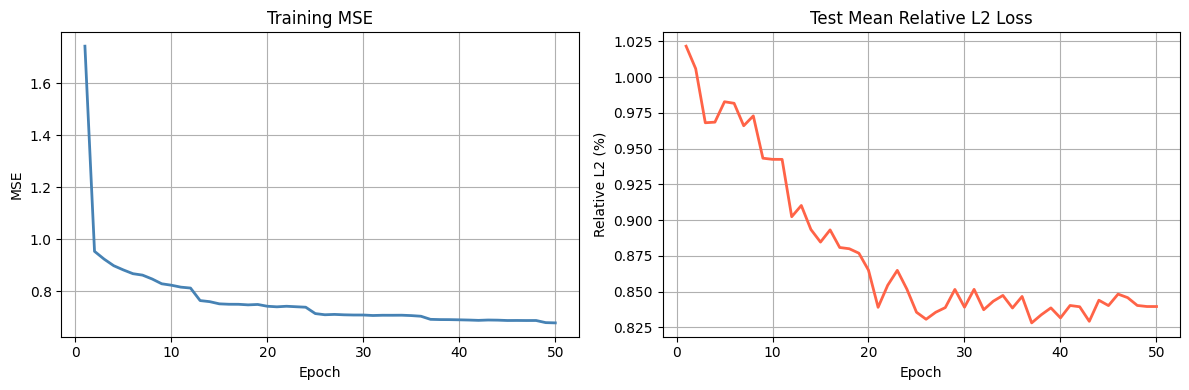

In [25]:
import os

epochs_range = range(1, epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, train_mse_history, color='steelblue', linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("Training MSE")
axes[0].grid(True)

axes[1].plot(epochs_range, test_rel_l2_history, color='tomato', linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Relative L2 (%)")
axes[1].set_title("Test Mean Relative L2 Loss")
axes[1].grid(True)

plt.tight_layout()

plots_dir = "training_plots"
os.makedirs(plots_dir, exist_ok=True)
fig.savefig(os.path.join(plots_dir, "training_curves.png"), dpi=150, bbox_inches="tight")
print(f"Plot saved to {plots_dir}/training_curves.png")

plt.show()

# Inference

How does our network do on infering the propagation of the network?

In [ ]:

# Load the model checkpoint (if applicable)

checkpoint = torch.load("trained_models/fno_fresnel.pth")
fno = FNO2d(checkpoint["fno_architecture"], device=device)
fno.load_state_dict(checkpoint["model_state_dict"])


sample_index = 50
input_sample = input_test[sample_index, :, :, :].unsqueeze(0).to(device)

# Extract the propagated field distance for reference

output_dist = input_sample[0,0,0,0]
print(output_dist)

fno.eval()
with torch.no_grad():
    output_pred = fno(input_sample)

# Reconstruct field from real and imaginary components

output_pred = output_pred.squeeze(0).cpu().numpy()
output_field = output_pred[..., 0] + 1j*output_pred[..., 1]

Select a sample at random fron the input data, and compute the output propagated field

In [ ]:
sample_index = 50
input_sample = input_test[sample_index, :, :, :].unsqueeze(0).to(device)

# Extract the propagated field distance for reference

output_dist = input_sample[0,0,0,0]
print(output_dist)

fno.eval()
with torch.no_grad():
    output_pred = fno(input_sample)

# Reconstruct field from real and imaginary components

output_pred = output_pred.squeeze(0).cpu().numpy()
output_field = output_pred[..., 0] + 1j*output_pred[..., 1]

Plot the input/output prediction

In [ ]:
# Extract input field (Re and Im) from input_sample
input_np = x_test[sample_index, :, :, :].cpu().numpy()  # (H, W, 3)
input_field = input_np[..., 1] + 1j * input_np[..., 2]     # Re + j*Im of input field
dist = input_np[0, 0, 0]                                    # propagation distance

# Extract ground truth output field
output_true_np = y_test[sample_index, :, :, :].cpu().numpy()  # (H, W, 2)
output_true_field = output_true_np[..., 0] + 1j * output_true_np[..., 1]

fig, axes = plt.subplots(3, 2, figsize=(10, 13))
fig.suptitle(f"Fresnel Propagation — Distance z = {dist:.4f}", fontsize=14)

im0 = axes[0, 0].imshow(np.abs(input_field), cmap='inferno')
axes[0, 0].set_title("Input Field — Amplitude")
plt.colorbar(im0, ax=axes[0, 0])

im1 = axes[0, 1].imshow(np.angle(input_field), cmap='hsv')
axes[0, 1].set_title("Input Field — Phase")
plt.colorbar(im1, ax=axes[0, 1])

im2 = axes[1, 0].imshow(np.abs(output_true_field), cmap='inferno')
axes[1, 0].set_title("True Output Field — Amplitude")
plt.colorbar(im2, ax=axes[1, 0])

im3 = axes[1, 1].imshow(np.angle(output_true_field), cmap='hsv')
axes[1, 1].set_title("True Output Field — Phase")
plt.colorbar(im3, ax=axes[1, 1])

im4 = axes[2, 0].imshow(np.abs(output_field), cmap='inferno')
axes[2, 0].set_title("Predicted Output Field — Amplitude")
plt.colorbar(im4, ax=axes[2, 0])

im5 = axes[2, 1].imshow(np.angle(output_field), cmap='hsv')
axes[2, 1].set_title("Predicted Output Field — Phase")
plt.colorbar(im5, ax=axes[2, 1])

plt.tight_layout()

plots_dir = "inference_plots"
os.makedirs(plots_dir, exist_ok=True)
fig.savefig(os.path.join(plots_dir, f"inference_sample{sample_index}.png"), dpi=150, bbox_inches="tight")
print(f"Plot saved to {plots_dir}/inference_sample{sample_index}.png")

plt.show()